In [1]:
##Business Problem and  Scope :

##The primary goal of this project  is to model energy production
##Scope of this project is to predict the power to be generated in units of Jules
##The variable to be predicted is continuous (energy production). 
##Based on the above information it is evident that this is a regression model/project
##The primary goal of a regression algorithm is to learn the relationship between input features (data points) 
##and a continuous output variable(energy production in this case)




In [2]:
##Business Objective:Anticipated Business Benefit
##Predecting the solar energy will help :
##1:optimize the  efficiency of solar power plants
##2:Helps to  manage  solar power plants.
##3:Helps the compaay to reduce costs,manage their solar systems in a  better way

In [3]:
##Key Terms from the dataset:

##distance-to-solar-noon: fundamental to calculating available solar power.
##closer the distance to solar noon, the greater the potential power output on a clear day.

##Sky-cover:Sky cover has a significant impact ons solar panel performance 
## clouds are the primary inhibitors of solar radiation reaching the Earth's surface.
##While panels still produce electricity on cloudy days,
##the output is substantially reduced compared to clear, sunny conditions
##w much of the sky is covered by clouds, affecting sunlight.

##average-pressure-(period): Avg atmospheric pressure over a specific time

##power-generated:Target variable:Represents the amount of power generated




In [4]:
##Our approach includes the following key steps:
"""
1.Data collection

2.EDA 
  Data Inspection,
  Data Loading,
  Understand data patterns-visualization(Histogram ,Bar graph,Box plots )
  
3.Preprocessing the data
   Remove outliers,
   Handle null values,
   Normalize data

4.Feature Selection

5.Model Selection & Building
Implement Linear Regression models on original  features and  PCA-transformed components

6.Training

7.Evaluation
 Assessing model performance using metrics such as Mean Squared Error (MSE) and R-squared.

8.Deployment of the model

9.Summary & Discussions
"""

'\n1.Data collection\n\n2.EDA \n  Data Inspection,\n  Data Loading,\n  Understand data patterns-visualization(Histogram ,Bar graph,Box plots )\n  \n3.Preprocessing the data\n   Remove outliers,\n   Handle null values,\n   Normalize data\n\n4.Feature Selection\n\n5.Model Selection & Building\nImplement Linear Regression models on original  features and  PCA-transformed components\n\n6.Training\n\n7.Evaluation\n Assessing model performance using metrics such as Mean Squared Error (MSE) and R-squared.\n\n8.Deployment of the model\n\n9.Summary & Discussions\n'

In [7]:
##Step1:Data Collection and Data loading
##import numpy as np
import pandas as pd
df = pd.read_csv("solarpowergeneration.csv")
df


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069
...,...,...,...,...,...,...,...,...,...,...
2915,0.166453,63,27,13.9,4,10.0,75,10.0,29.93,6995
2916,0.064020,63,27,13.9,1,10.0,66,15.0,29.91,29490
2917,0.294494,63,27,13.9,2,10.0,68,21.0,29.88,17257
2918,0.524968,63,27,13.9,2,10.0,81,17.0,29.87,677


In [8]:
##Finding out the datatypes of the independent variables & depenedent variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [9]:
##Check for null values in the data
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64

In [10]:
##It is evident that average-wind-speed-(period) has a null value

In [11]:
##Display the record with null value
null_value = df[df['average-wind-speed-(period)'].isnull()]
display(null_value)
    


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
714,0.406143,57,12,2.8,2,4.0,96,NaN,30.16,159


In [12]:
##Replace the null value with the mean of the corresponding column
meanofwindspeed = df['average-wind-speed-(period)'].mean()
print(f"Mean of 'average-wind-speed-(period)': {meanofwindspeed }")

df['average-wind-speed-(period)']=df['average-wind-speed-(period)'].fillna(meanofwindspeed )


Mean of 'average-wind-speed-(period)': 10.129153819801301


In [13]:
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

In [14]:
if df.duplicated().any():
   duplicaterows=df[df.duplicated(keep=False)]
   print("Duplicate rows found:")
   print("Number of dupliate rows is :",len(duplicaterows))
   display(duplicaterows)
else:
  print("No duplicate rows found in the original data set.")




No duplicate rows found in the original data set.


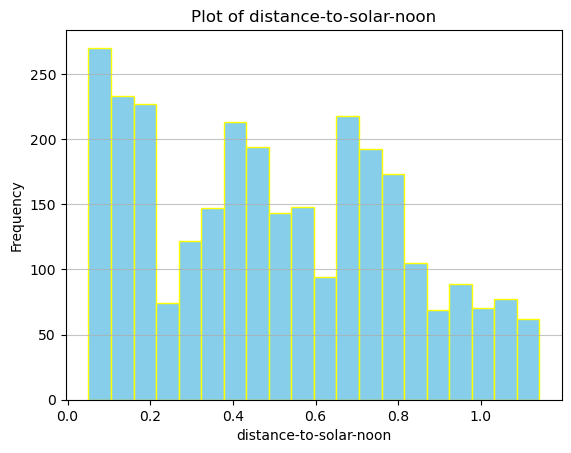

Mean of distance-to-solar-noon: 0.50
Median of distance-to-solar-noon: 0.48


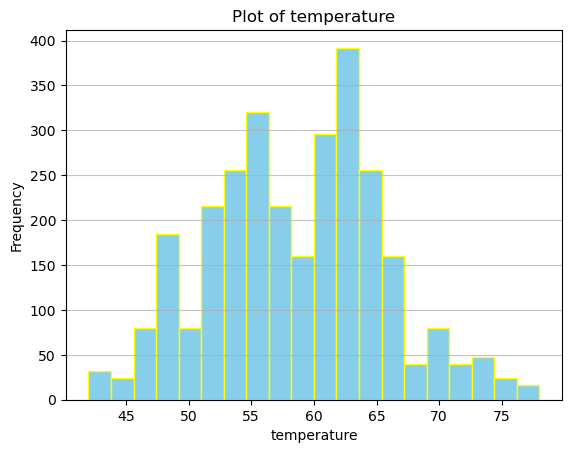

Mean of temperature: 58.47
Median of temperature: 59.00


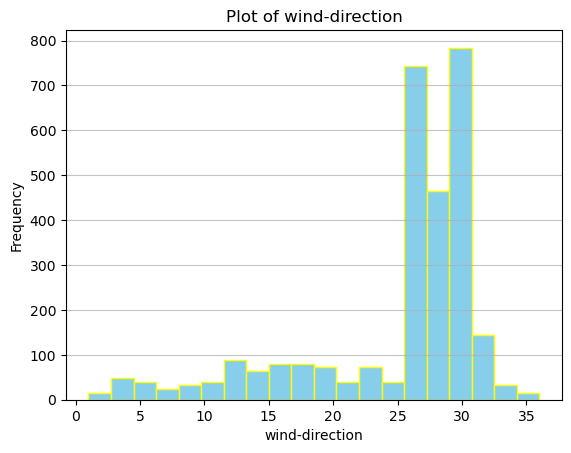

Mean of wind-direction: 24.95
Median of wind-direction: 27.00


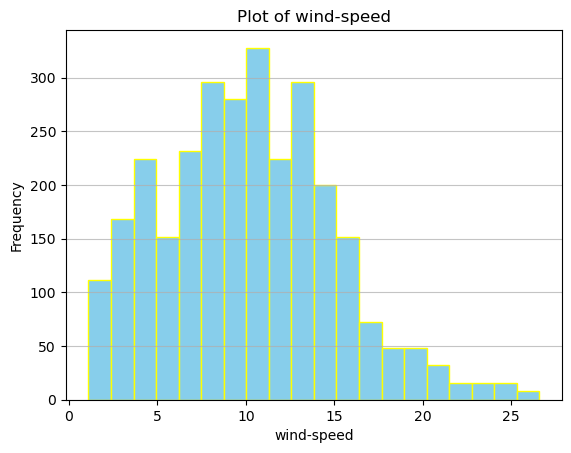

Mean of wind-speed: 10.10
Median of wind-speed: 10.00


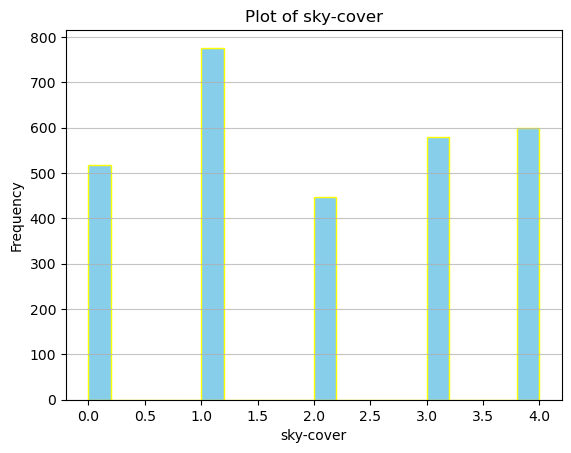

Mean of sky-cover: 1.99
Median of sky-cover: 2.00


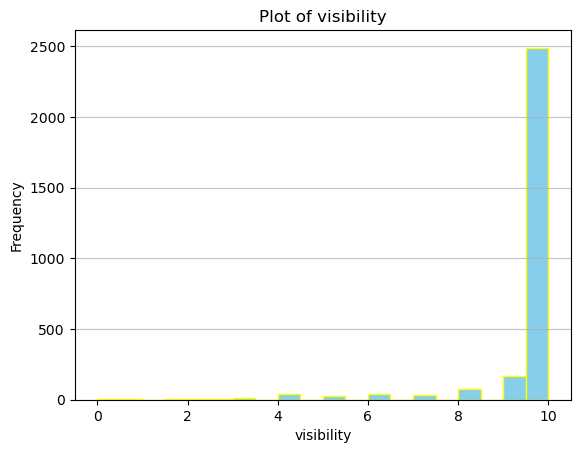

Mean of visibility: 9.56
Median of visibility: 10.00


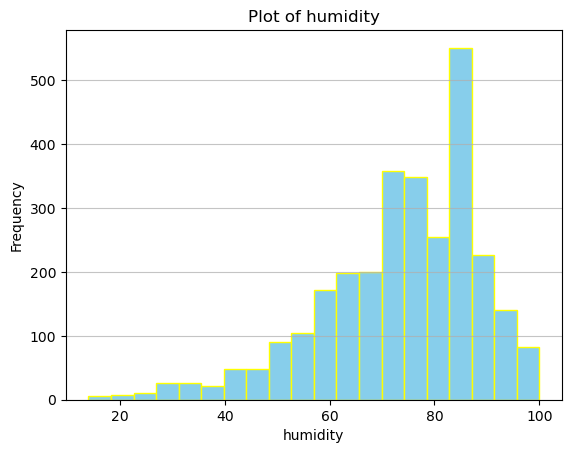

Mean of humidity: 73.51
Median of humidity: 77.00


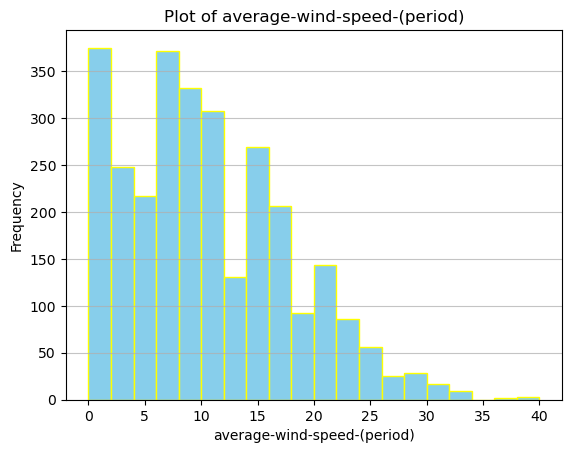

Mean of average-wind-speed-(period): 10.13
Median of average-wind-speed-(period): 9.00


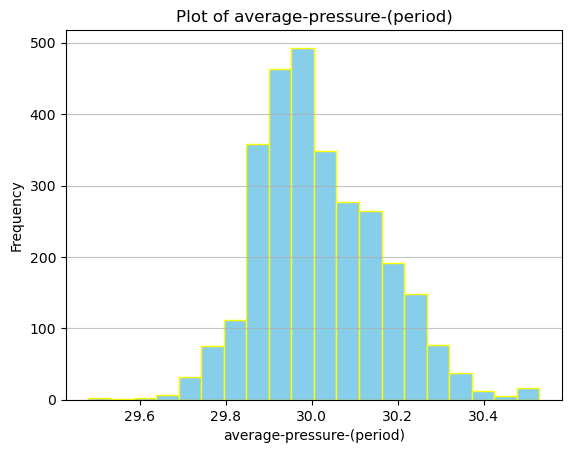

Mean of average-pressure-(period): 30.02
Median of average-pressure-(period): 30.00


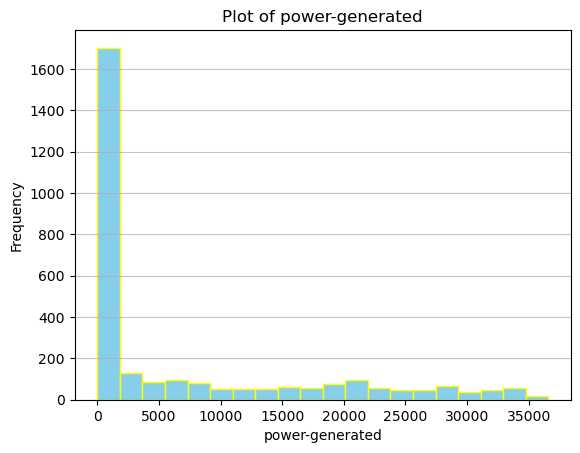

Mean of power-generated: 6979.85
Median of power-generated: 404.00


In [15]:
#Undesrtanding the distribution of individual independent variables through Histogram


import matplotlib.pyplot as plt 

        
for i in df.columns:
        
        
        plt.hist(df[i],color='skyblue',bins=20,edgecolor='yellow')
    
        plt.title(f'Plot of {i}')
        plt.xlabel(i)
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.75)
        plt.show()
        print(f"Mean of {i}: {df[i].mean():.2f}")
        print(f"Median of {i}: {df[i].median():.2f}")
    
  
  

In [16]:
"""Inference: 

Mean of distance-to-solar-noon: 0.50
Median of distance-to-solar-noon: 0.48
Mean close to Median so data normally distributed


Mean of temperature: 58.47
Median of temperature: 59.00

Mean almost equal to Median so this indicates a normal distribution

Mean of wind-direction: 24.95
Median of wind-direction: 27.00
Mean<Median so data slighlty leftskewed

Mean of sky-cover: 1.99
Median of sky-cover: 2.00
Data is Noramlly distributed
Most of the sky-cover observations are concentrated around 'scattered' (2) or higher values.


Mean of visibility: 9.56
Median of visibility: 10.00
Mean<Medain so data leftskewed

Mean of humidity: 73.51
Median of humidity: 77.00
Mean<Medain so data leftskewed


Mean of average-wind-speed-(period): 10.13
Median of average-wind-speed-(period): 9.00
Mean>Medain so data rightskewed


Mean of average-pressure-(period): 30.02
Median of average-pressure-(period): 30.00
this distribution is very symmetric 

SyntaxError: incomplete input (3336898227.py, line 1)

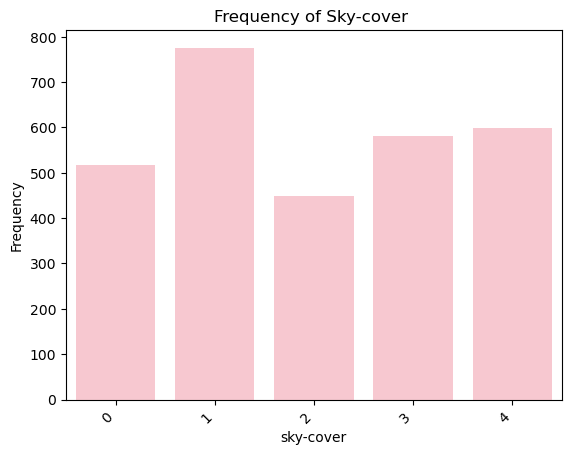

In [17]:
##Bar charts to visualize the frequency of SKU
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='sky-cover', data=df,color='pink')
plt.title('Frequency of Sky-cover ',)
plt.xlabel('sky-cover')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right') 
plt.show()

In [18]:
""The most frequent sky cover value is 1, with 776 occurrences. 

SyntaxError: invalid syntax (1186020171.py, line 1)

<Axes: >

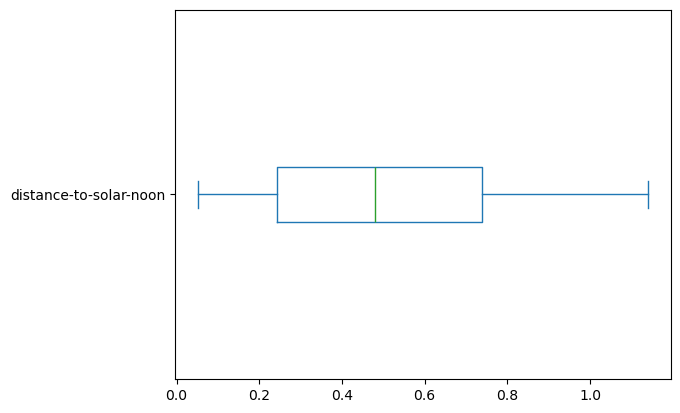

In [19]:
import matplotlib.pyplot as plt

##Boxplotto identify outliers
# box plot
df["distance-to-solar-noon"].plot(kind='box',vert=False)

In [20]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["distance-to-solar-noon"],25)
Q3 = np.percentile(df["distance-to-solar-noon"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['distance-to-solar-noon'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'distance-to-solar-noon'])<LW:
        df.loc[i,'distance-to-solar-noon']=LW
        s=s+1
    elif (df.loc[i,'distance-to-solar-noon'])>UW: # Added condition for upper outliers
        df.loc[i,'distance-to-solar-noon']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps



IQRvalue 0.49581353274999995
Upper wisker length, 1.4832478081249998
Lower wisker length -0.5000063228749999
number of outlier replaced 0


<Axes: >

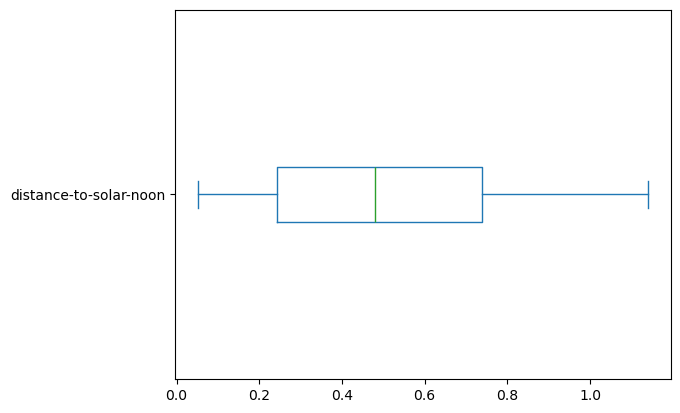

In [21]:

##Boxplotto identify outliers
# box plot
df["distance-to-solar-noon"].plot(kind='box',vert=False)

<Axes: >

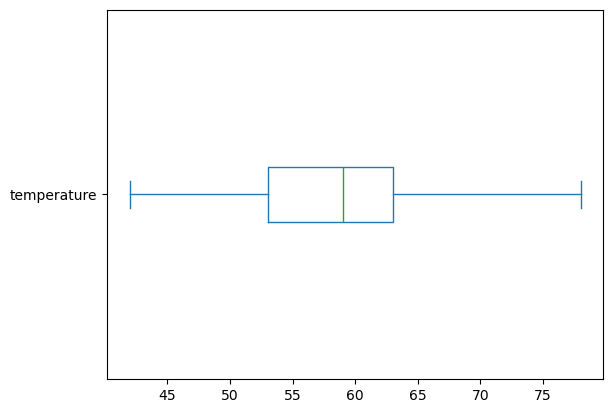

In [22]:
##Boxplotto identify outliers
# box plot
df["temperature"].plot(kind='box',vert=False)

<Axes: >

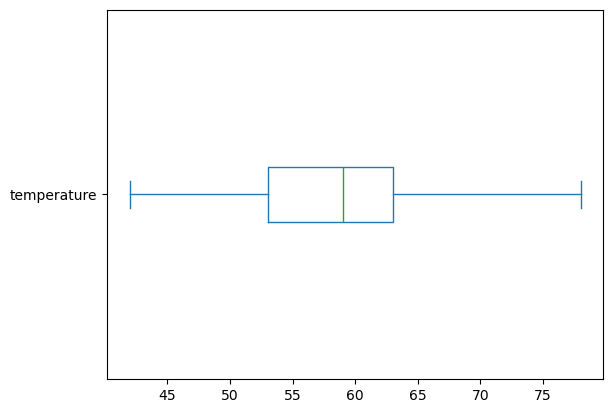

In [23]:
##Boxplotto identify outliers
# box plot
df["temperature"].plot(kind='box',vert=False)

In [24]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["temperature"],25)
Q3 = np.percentile(df["temperature"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['temperature'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'temperature'])<LW:
        df.loc[i,'temperature']=LW
        s=s+1
    elif (df.loc[i,'temperature'])>UW: # Added condition for upper outliers
        df.loc[i,'temperature']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps


IQRvalue 10.0
Upper wisker length, 78.0
Lower wisker length 38.0
number of outlier replaced 0


<Axes: >

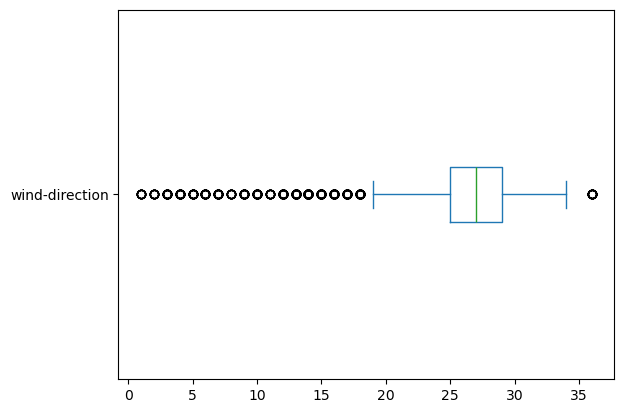

In [25]:
##Boxplotto identify outliers
# box plot
df["wind-direction"].plot(kind='box',vert=False)

In [26]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["wind-direction"],25)
Q3 = np.percentile(df["wind-direction"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['wind-direction'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'wind-direction'])<LW:
        df.loc[i,'wind-direction']=LW
        s=s+1
    elif (df.loc[i,'wind-direction'])>UW: # Added condition for upper outliers
        df.loc[i,'wind-direction']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps



IQRvalue 4.0
Upper wisker length, 35.0
Lower wisker length 19.0
number of outlier replaced 528


<Axes: >

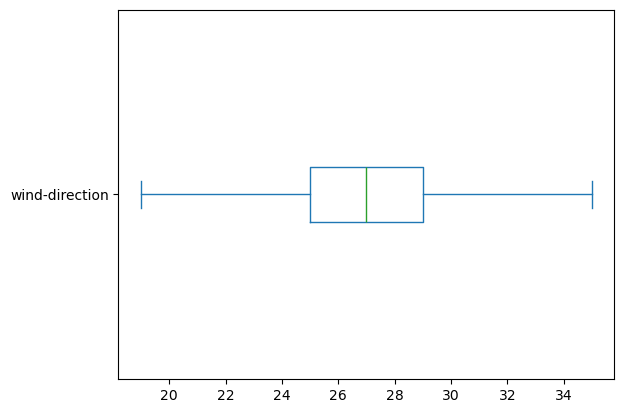

In [27]:
df["wind-direction"].plot(kind='box',vert=False)

<Axes: >

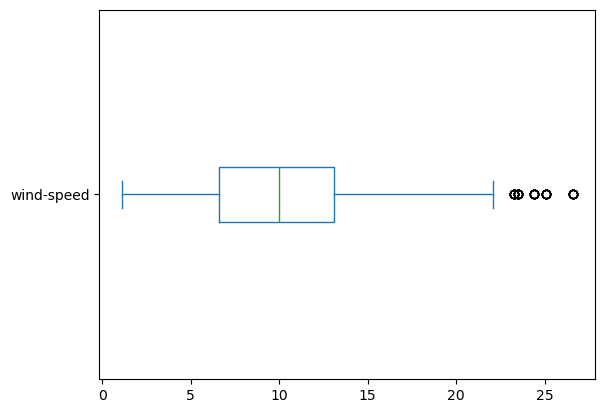

In [28]:
##Boxplotto identify outliers
# box plot
df["wind-speed"].plot(kind='box',vert=False)

In [29]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["wind-speed"],25)
Q3 = np.percentile(df["wind-speed"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['wind-speed'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'wind-speed'])<LW:
        df.loc[i,'wind-speed']=LW
        s=s+1
    elif (df.loc[i,'wind-speed'])>UW: # Added condition for upper outliers
        df.loc[i,'wind-speed']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps


IQRvalue 6.5
Upper wisker length, 22.85
Lower wisker length -3.1500000000000004
number of outlier replaced 40


<Axes: >

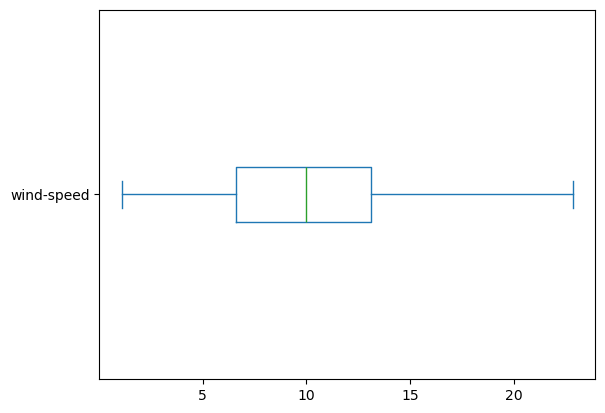

In [30]:
##Boxplotto identify outliers
# box plot
df["wind-speed"].plot(kind='box',vert=False)

<Axes: >

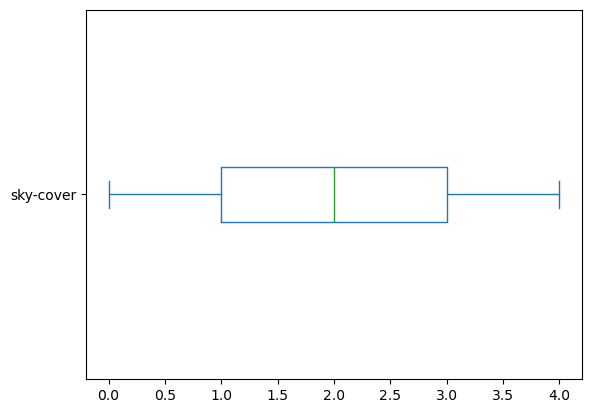

In [31]:
##Boxplotto identify outliers
# box plot
df["sky-cover"].plot(kind='box',vert=False)

In [32]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["sky-cover"],25)
Q3 = np.percentile(df["sky-cover"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['sky-cover'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'sky-cover'])<LW:
        df.loc[i,'sky-cover']=LW
        s=s+1
    elif (df.loc[i,'sky-cover'])>UW: # Added condition for upper outliers
        df.loc[i,'sky-cover']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps

IQRvalue 2.0
Upper wisker length, 6.0
Lower wisker length -2.0
number of outlier replaced 0


<Axes: >

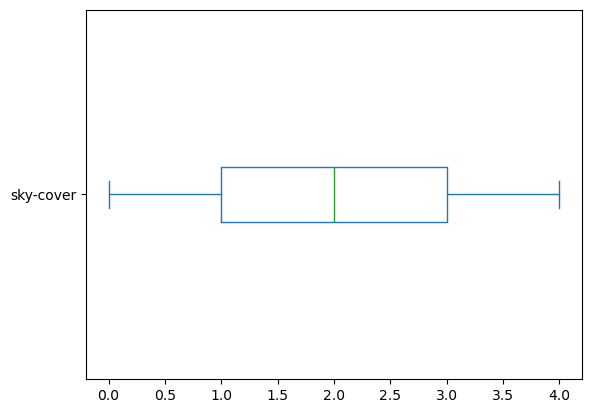

In [33]:
##Boxplotto identify outliers
# box plot
df["sky-cover"].plot(kind='box',vert=False)

<Axes: >

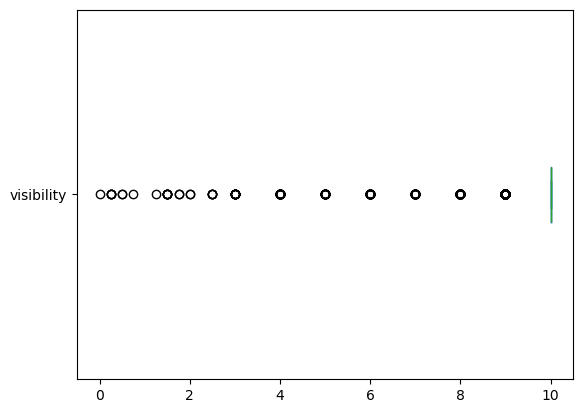

In [34]:
# box plot
df["visibility"].plot(kind='box',vert=False)

In [35]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["visibility"],25)
Q3 = np.percentile(df["visibility"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['visibility'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'visibility'])<LW:
        df.loc[i,'visibility']=LW
        s=s+1
    elif (df.loc[i,'visibility'])>UW: # Added condition for upper outliers
        df.loc[i,'visibility']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps


IQRvalue 0.0
Upper wisker length, 10.0
Lower wisker length 10.0
number of outlier replaced 429


<Axes: >

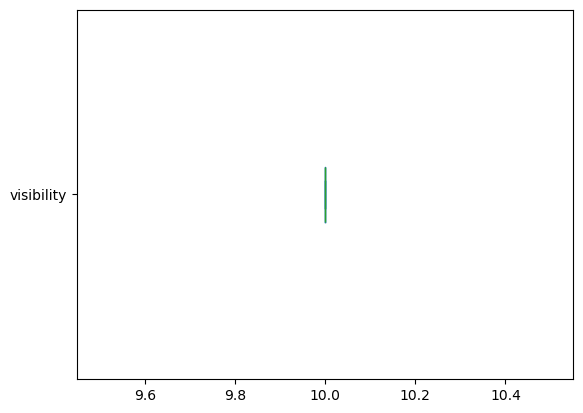

In [36]:
##Boxplotto identify outliers
# box plot
df["visibility"].plot(kind='box',vert=False)

<Axes: >

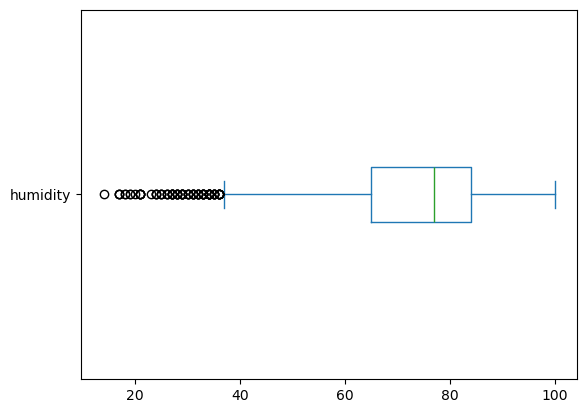

In [37]:
##Boxplotto identify outliers
# box plot
df["humidity"].plot(kind='box',vert=False)

In [38]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["humidity"],25)
Q3 = np.percentile(df["humidity"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['humidity'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'humidity'])<LW:
        df.loc[i,'humidity']=LW
        s=s+1
    elif (df.loc[i,'humidity'])>UW: # Added condition for upper outliers
        df.loc[i,'humidity']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps

IQRvalue 19.0
Upper wisker length, 112.5
Lower wisker length 36.5
number of outlier replaced 83


C:\Users\mihir\AppData\Local\Temp\ipykernel_6304\3711529752.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '36.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'humidity']=LW


<Axes: >

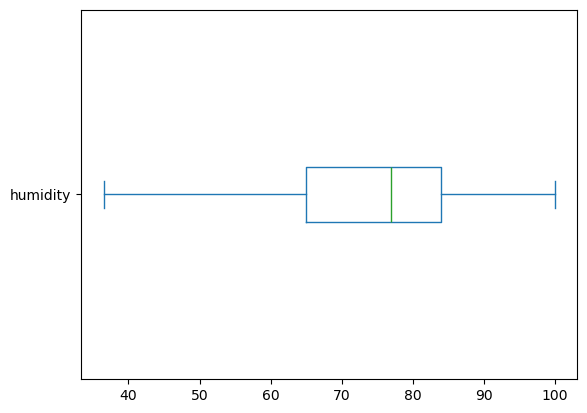

In [39]:
##Boxplotto identify outliers
# box plot
df["humidity"].plot(kind='box',vert=False)
##there are no explicit outlier points displayed for 'humidity'

<Axes: >

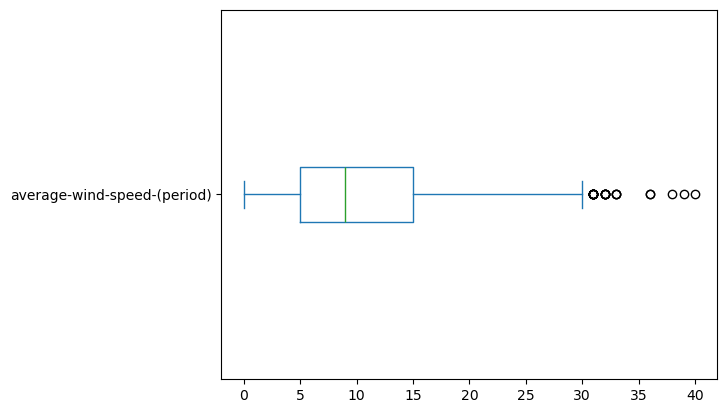

In [40]:
##Boxplotto identify outliers
# box plot
df["average-wind-speed-(period)"].plot(kind='box',vert=False)


In [41]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["average-wind-speed-(period)"],25)
Q3 = np.percentile(df["average-wind-speed-(period)"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['average-wind-speed-(period)'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'average-wind-speed-(period)'])<LW:
        df.loc[i,'average-wind-speed-(period)']=LW
        s=s+1
    elif (df.loc[i,'average-wind-speed-(period)'])>UW: # Added condition for upper outliers
        df.loc[i,'average-wind-speed-(period)']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps

IQRvalue 10.0
Upper wisker length, 30.0
Lower wisker length -10.0
number of outlier replaced 25


<Axes: >

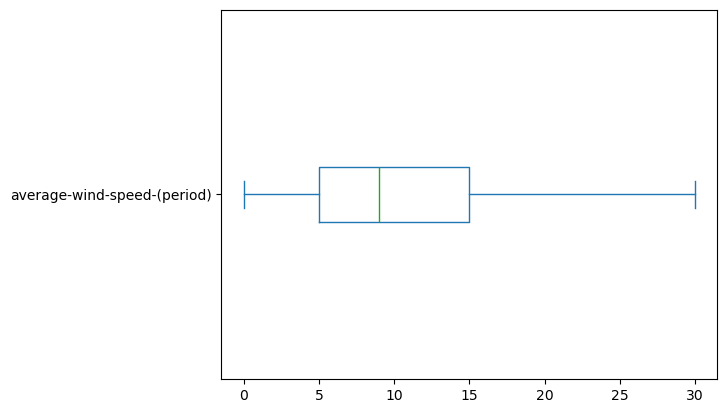

In [42]:
##Boxplotto identify outliers
# box plot
df["average-wind-speed-(period)"].plot(kind='box',vert=False)

<Axes: >

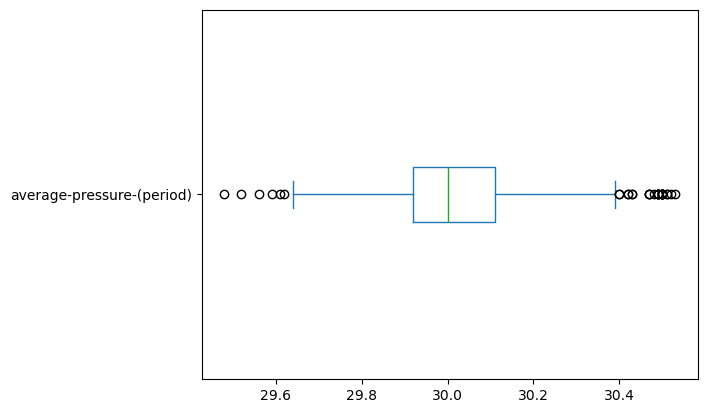

In [43]:
##Boxplotto identify outliers
# box plot
df["average-pressure-(period)"].plot(kind='box',vert=False)

In [44]:
##Replace outlier with lower & Upper wisker length
import numpy as np
Q1 = np.percentile(df["average-pressure-(period)"],25)
Q3 = np.percentile(df["average-pressure-(period)"],75)
IQR = Q3-Q1
print("IQRvalue",IQR)
UW = Q3+1.5*IQR
LW = Q1-1.5*IQR
print("Upper wisker length,",UW)
print("Lower wisker length",LW)
##Find the total length of the variable
##Looping till the last element 
##Within the loop check if each value<LW .If so replace with LW value

c=len(df['average-pressure-(period)'])
s=0
for i in range(0,c):
    
    
    if (df.loc[i,'average-pressure-(period)'])<LW:
        df.loc[i,'average-pressure-(period)']=LW
        s=s+1
    elif (df.loc[i,'average-pressure-(period)'])>UW: # Added condition for upper outliers
        df.loc[i,'average-pressure-(period)']=UW
        s=s+1
      
print ("number of outlier replaced",s)
##Check if outlier replaced byplotting box plot again
##Same logic have implemented for other variables below hence not commenting/elaborating steps

IQRvalue 0.18999999999999773
Upper wisker length, 30.394999999999996
Lower wisker length 29.635000000000005
number of outlier replaced 31


<Axes: >

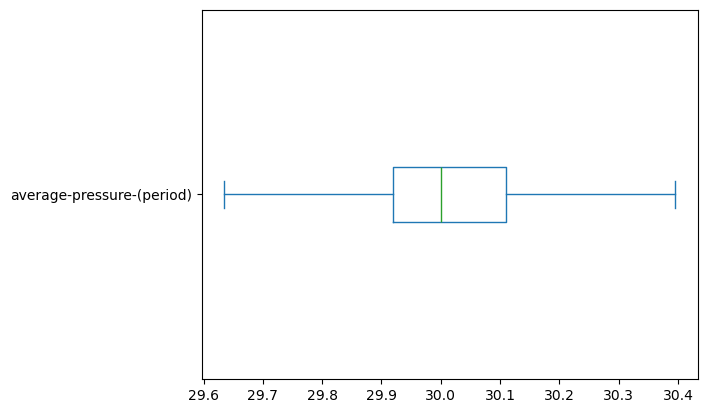

In [45]:
##Boxplotto identify outliers
# box plot
df["average-pressure-(period)"].plot(kind='box',vert=False)

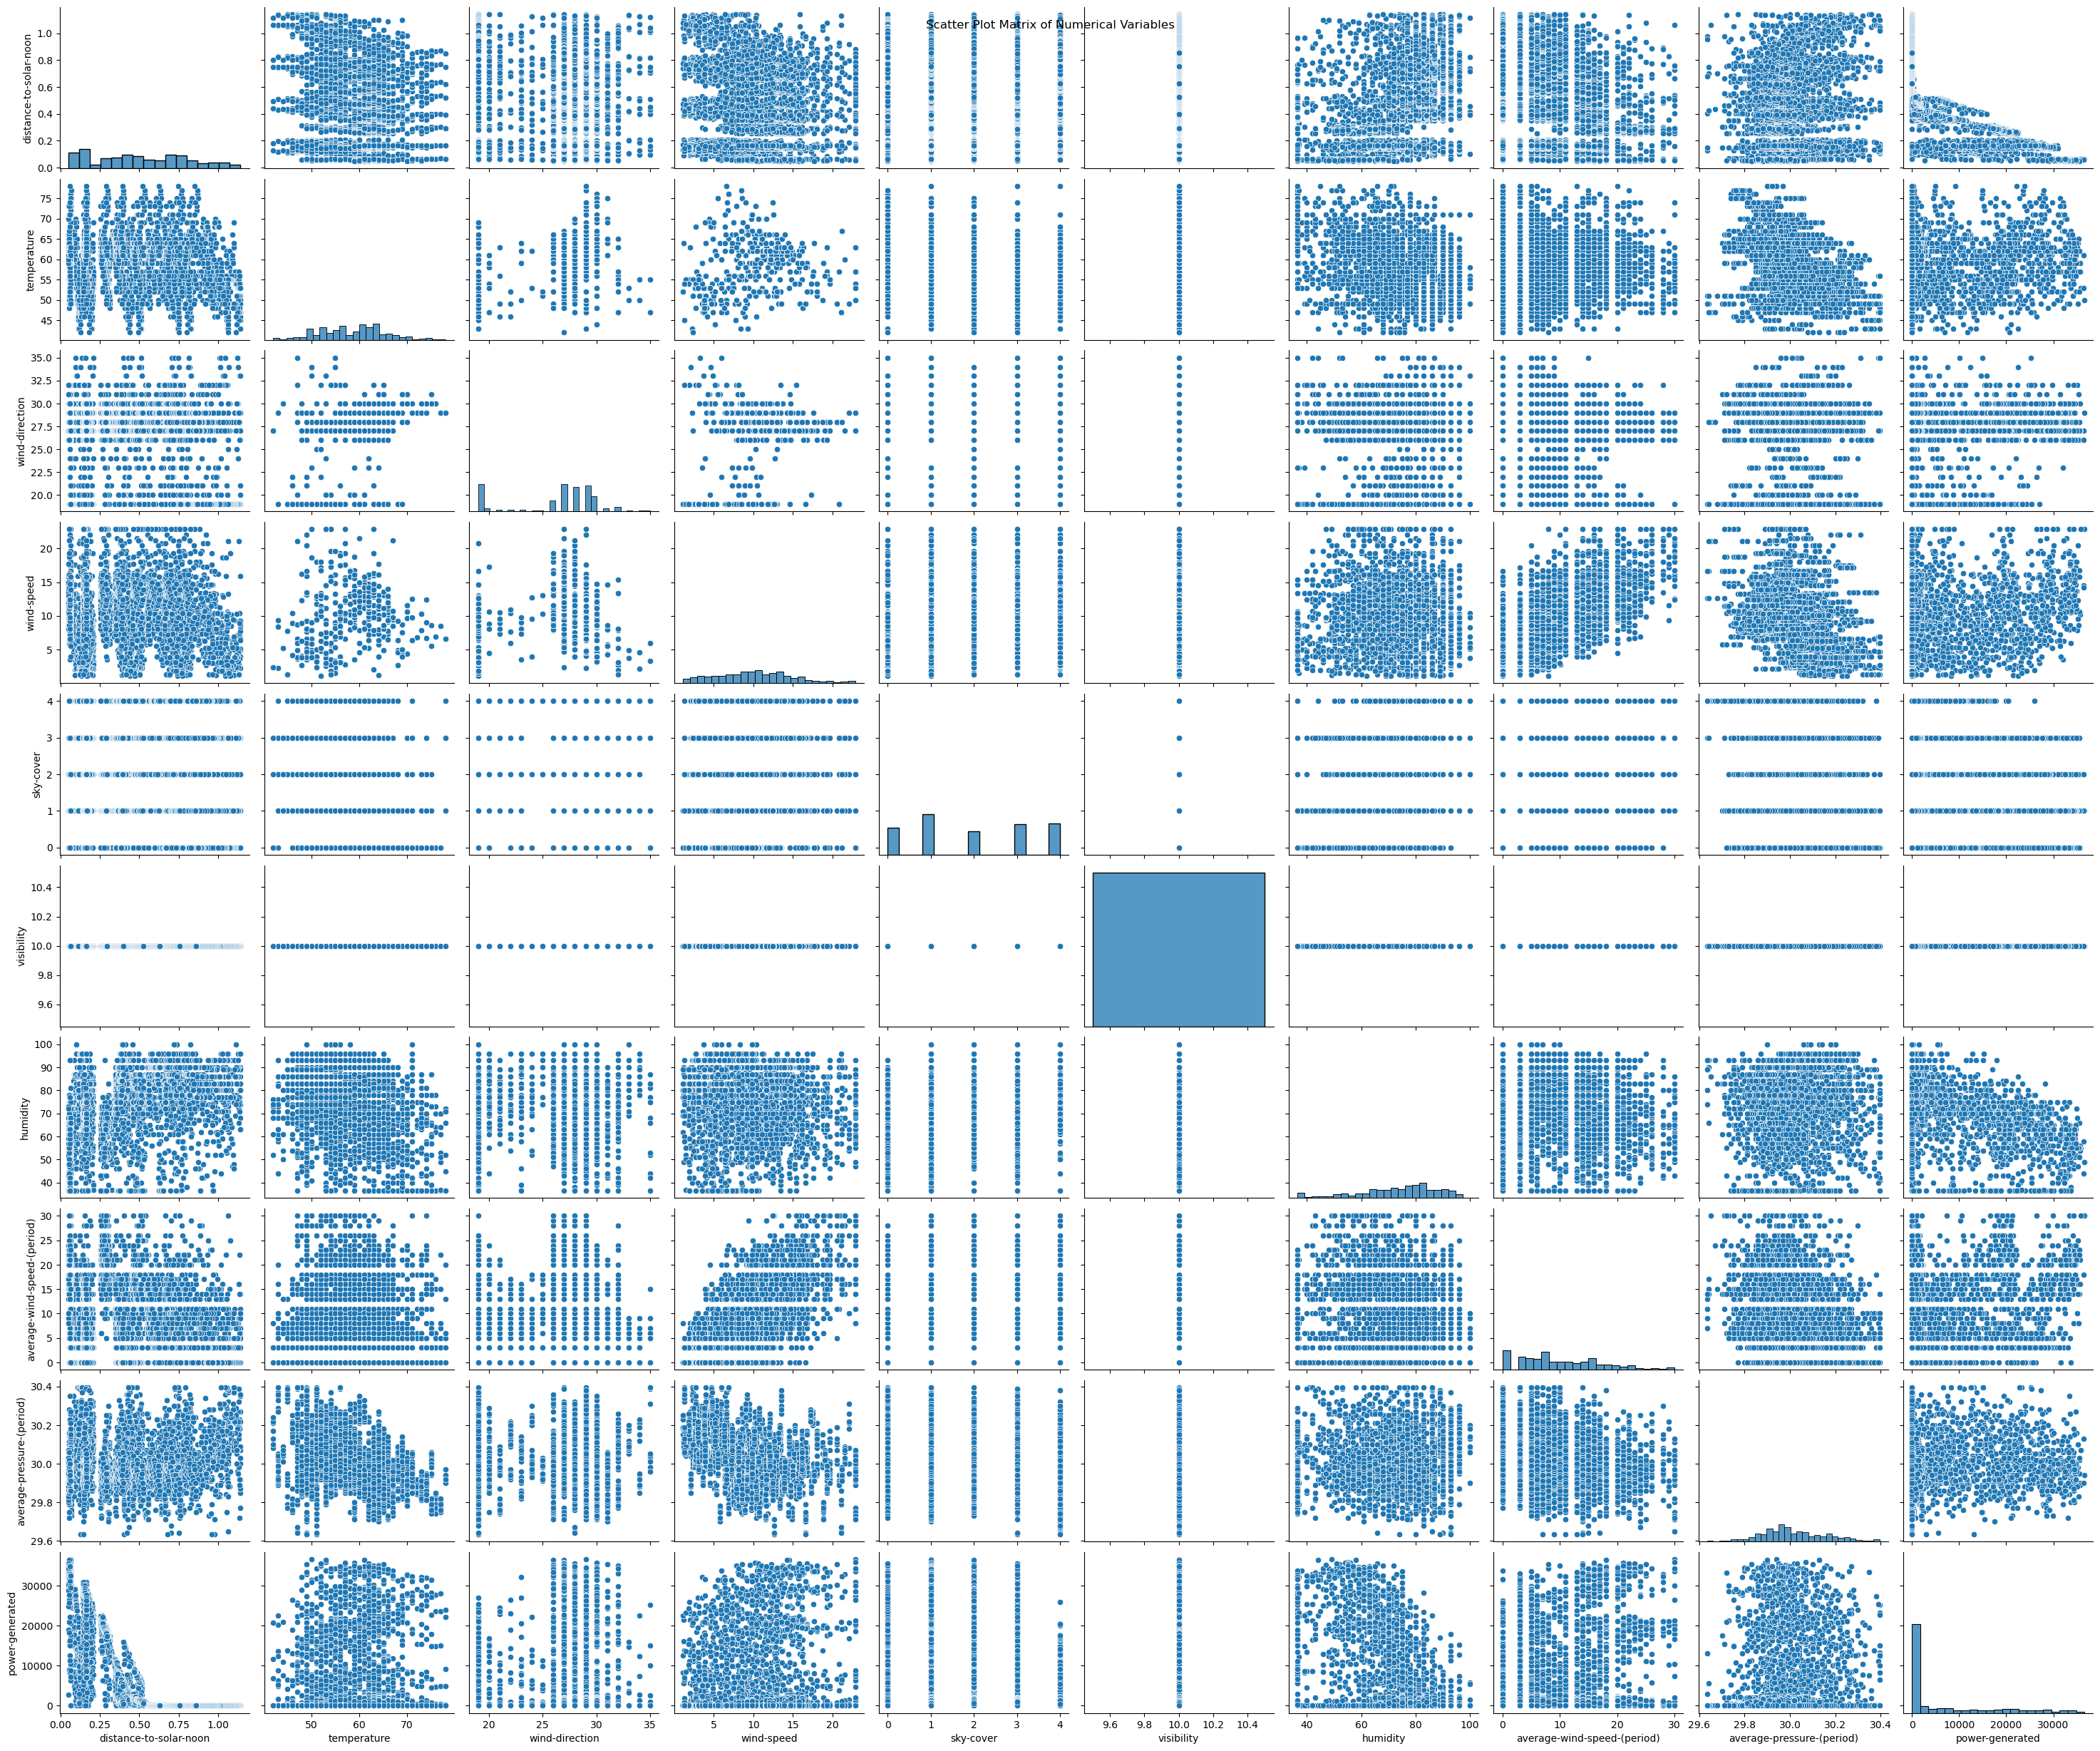

In [46]:
##generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
numerical_cols = df.select_dtypes(include=['number'])
import seaborn as sns
# Create a scatter plot matrix
import matplotlib.pyplot as plt 
sns.pairplot(numerical_cols, height=2.5, aspect=1.2)
plt.suptitle('Scatter Plot Matrix of Numerical Variables')
plt.show()

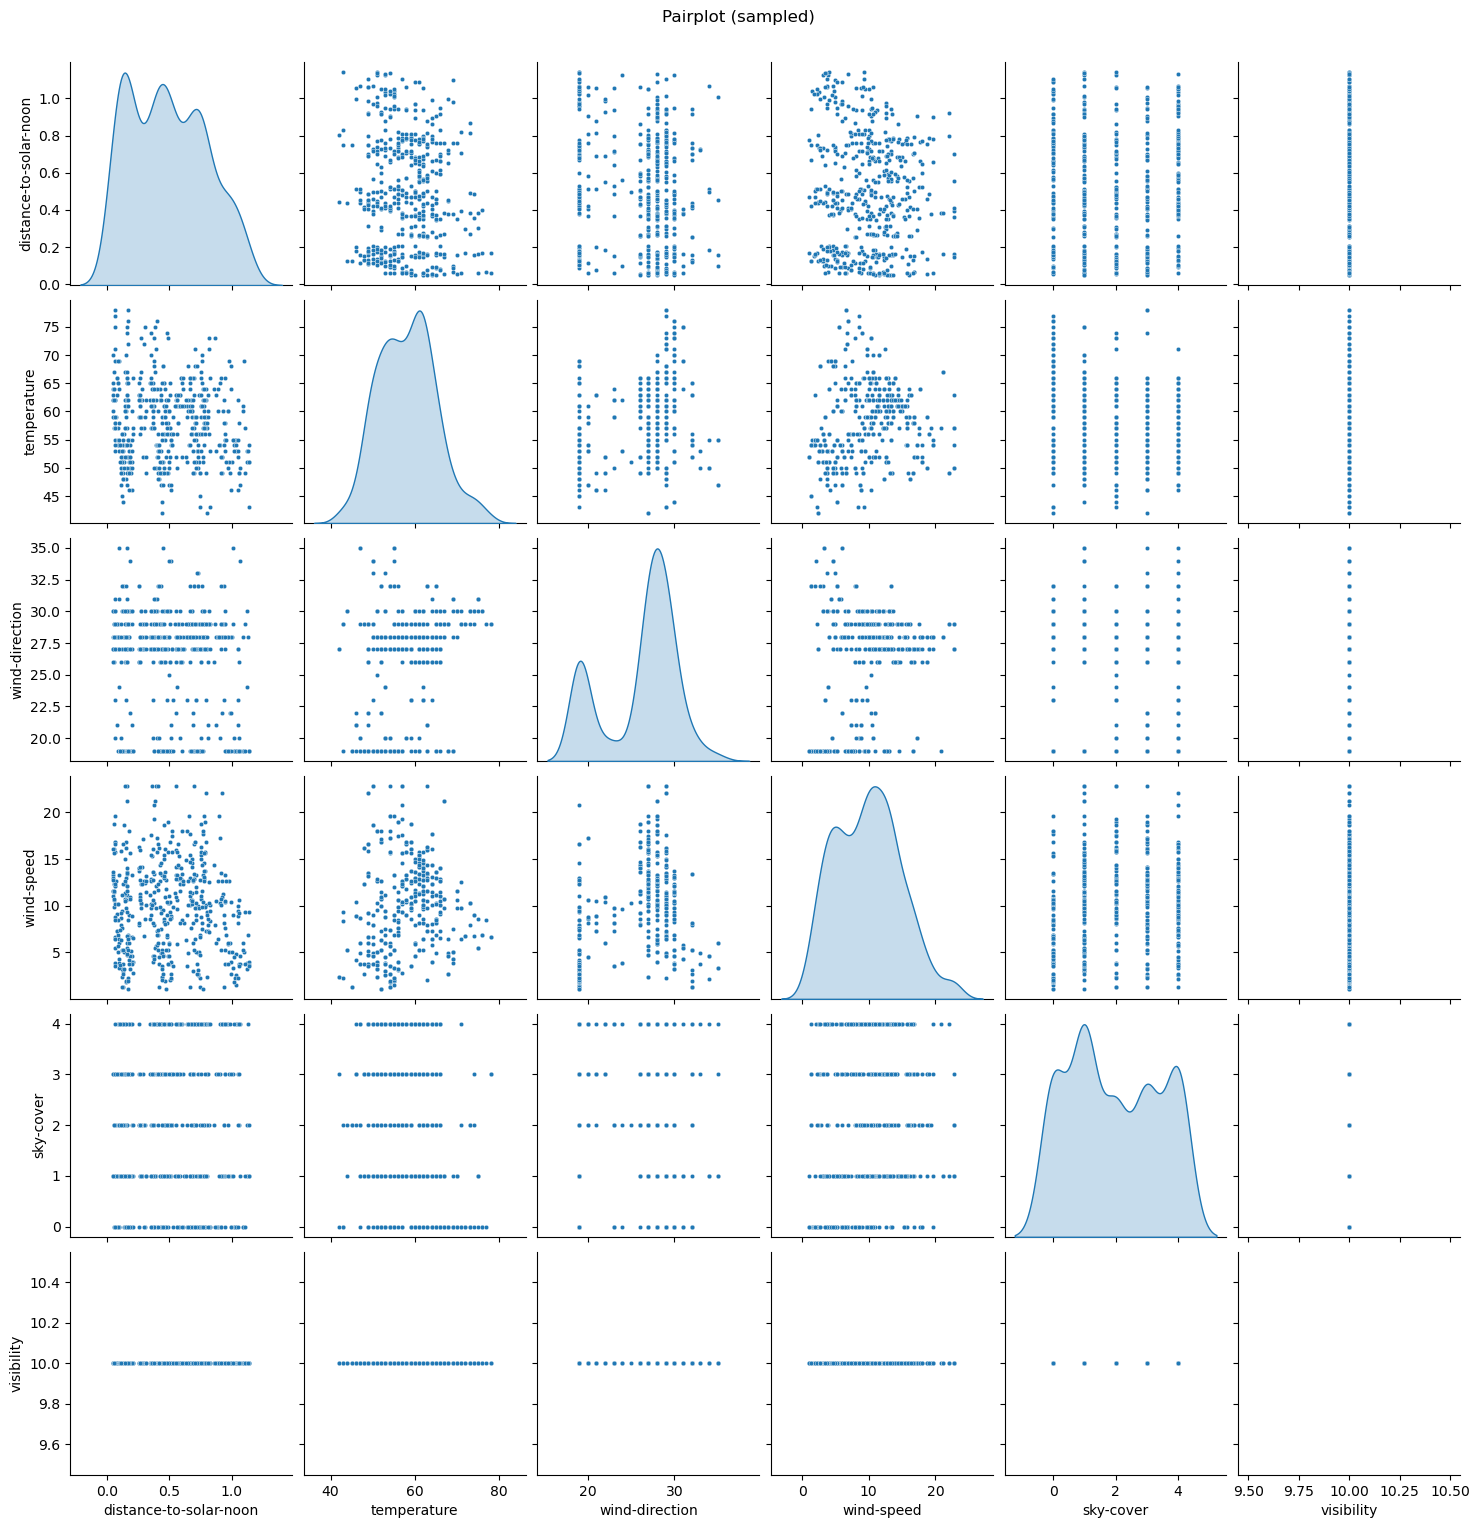

In [47]:

numeric_cols = df.select_dtypes(include=['number']).columns
cols_for_pair = numeric_cols[:6] if len(numeric_cols) > 6 else numeric_cols
sns.pairplot(df[cols_for_pair].sample(n=min(500, len(df))), diag_kind='kde', plot_kws={'s': 10})
plt.suptitle("Pairplot (sampled)", y=1.02)
plt.show()

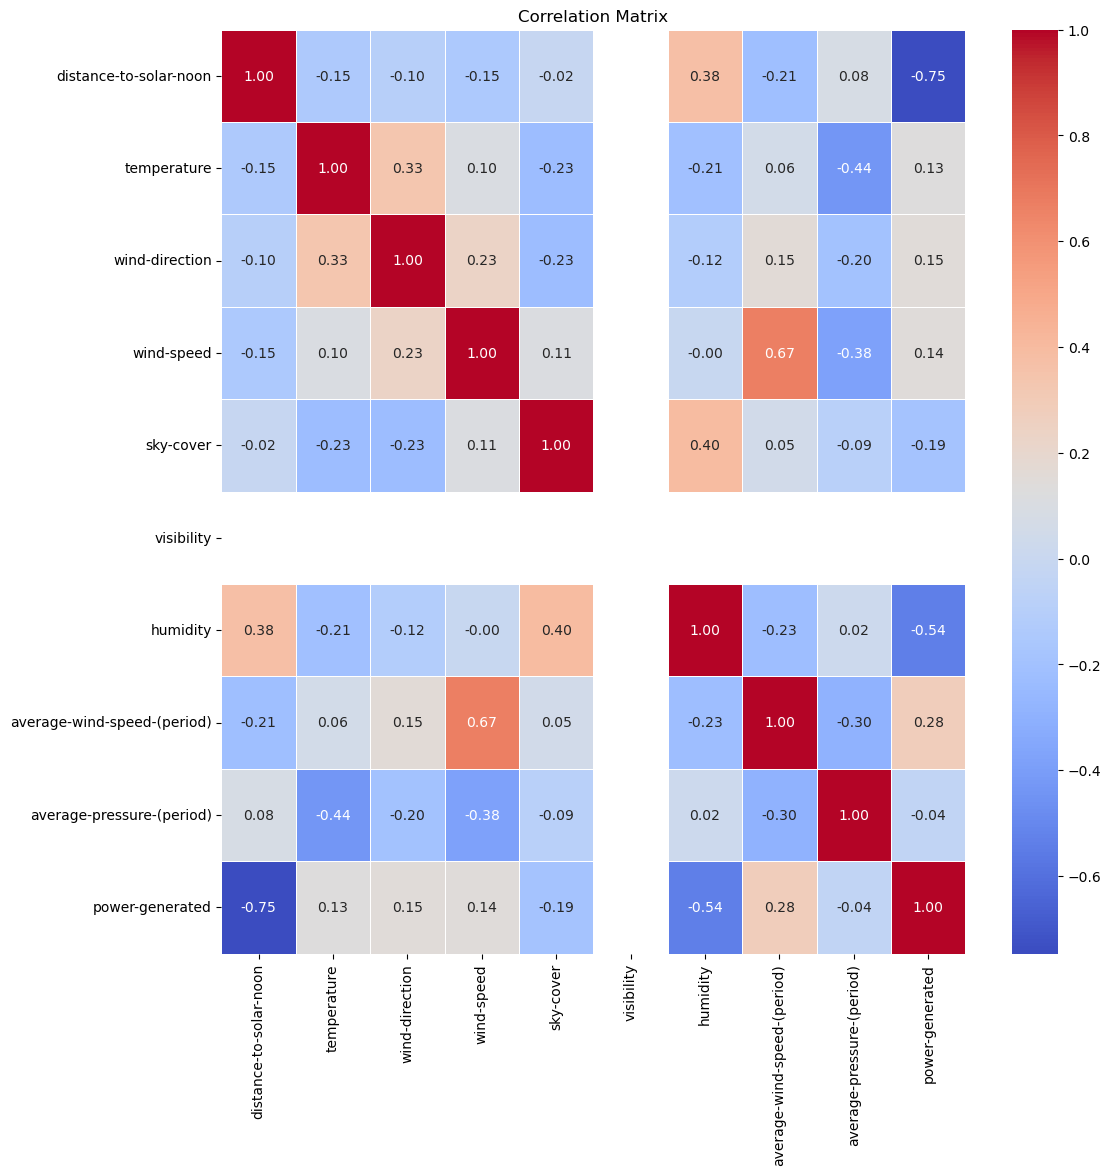

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create map of the correlation matrix
plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [51]:
"""Inference
Independent features with Target Variable
*****************************************
distance-to-solar-noon vs power-generated -.74
humidity vs power-generated -.5
'distance-to-solar-noon' is   strongest predictor/independent feature for 'power-generated' 
followed by 'humidity

Correlation between Independent variables
******************************************

temperature vs average-pressure-(period) -.43
wind-speed	 vs average-wind-speed-(period) .67
Humidity vs sky cover .39

We can conclude that multicollinearity exists between wind-speed & average-wind-speed-(period) 
due to strong positive correlation
Other values suggest moderate correlation between independent variables"""

"Inference\nIndependent features with Target Variable\n*****************************************\ndistance-to-solar-noon vs power-generated -.74\nhumidity vs power-generated -.5\n'distance-to-solar-noon' is   strongest predictor/independent feature for 'power-generated' \nfollowed by 'humidity\n\nCorrelation between Independent variables\n******************************************\n\ntemperature vs average-pressure-(period) -.43\nwind-speed\t vs average-wind-speed-(period) .67\nHumidity vs sky cover .39\n\nWe can conclude that multicollinearity exists between wind-speed & average-wind-speed-(period) \ndue to strong positive correlation\nOther values suggest moderate correlation between independent variables"

In [52]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler




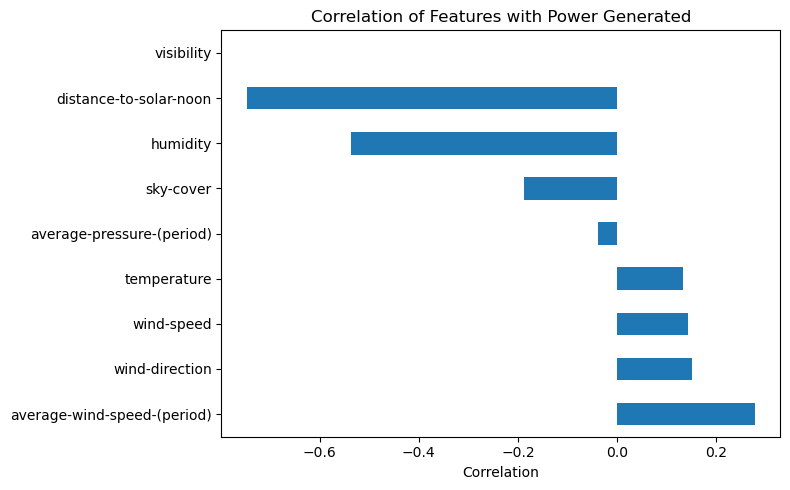

In [53]:
import matplotlib.pyplot as plt

target_col = "power-generated"

corr = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values(ascending=False)

plt.figure(figsize=(8,5))
corr.plot(kind="barh")
plt.title("Correlation of Features with Power Generated")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


In [54]:

# -------------------------------
#  Target and Features
# -------------------------------
target_col = "power-generated"

X = df.drop(target_col, axis=1)
y = df[target_col]


In [55]:

# -------------------------------
#  Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [56]:

# -------------------------------
#  Scaling (for Linear/Ridge)
# -------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Full scaled X for CV (for Linear/Ridge)
X_scaled_full = scaler.fit_transform(X)

In [57]:
''' 
                                       Why scaling only for Linear & Ridge

1) Scaling is applied only for Linear Regression and Ridge Regression because these models are sensitive
   to feature magnitude.
2) Features like visibility, pressure, humidity etc. are in different units and ranges, so scaling
   helps coefficients learn fairly.
3) Tree-based models (Random Forest, Gradient Boosting) do not require scaling because they split data 
   using thresholds, not distances.
'''

' \n                                       Why scaling only for Linear & Ridge\n\n1) Scaling is applied only for Linear Regression and Ridge Regression because these models are sensitive\n   to feature magnitude.\n2) Features like visibility, pressure, humidity etc. are in different units and ranges, so scaling\n   helps coefficients learn fairly.\n3) Tree-based models (Random Forest, Gradient Boosting) do not require scaling because they split data \n   using thresholds, not distances.\n'

In [58]:
#                                                   1.  LINEAR MODEL

In [59]:

linear_model = LinearRegression()

# Fit Model
linear_model.fit(X_train_scaled, y_train)

train_pred = linear_model.predict(X_train_scaled)
test_pred  = linear_model.predict(X_test_scaled)

print("\nTrain MAE for LINEAR MODEL:", mean_absolute_error(y_train, train_pred))
print("Test  MAE for LINEAR MODEL:", mean_absolute_error(y_test, test_pred))

print("\nTrain RMSE for LINEAR MODEL:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test  RMSE for LINEAR MODEL:", np.sqrt(mean_squared_error(y_test, test_pred)))

print("\nTrain R2  for LINEAR MODEL:", r2_score(y_train, train_pred))
print("Test  R2  for LINEAR MODEL:", r2_score(y_test, test_pred))



Train MAE for LINEAR MODEL: 4868.686707757777
Test  MAE for LINEAR MODEL: 4953.910895847403

Train RMSE for LINEAR MODEL: 6040.834980650019
Test  RMSE for LINEAR MODEL: 6237.590766629653

Train R2  for LINEAR MODEL: 0.6575086298603967
Test  R2  for LINEAR MODEL: 0.6306378808504128


In [60]:
'''
1) Cross-validation is used to evaluate the model more reliably by testing on multiple splits
   instead of a single train-test split.
2) This gives a stable estimate of real-world performance and reduces dependency on one random split.
 '''

'\n1) Cross-validation is used to evaluate the model more reliably by testing on multiple splits\n   instead of a single train-test split.\n2) This gives a stable estimate of real-world performance and reduces dependency on one random split.\n '

In [61]:
#    Cross Validation on Linear Model

from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    linear_model, X_scaled_full, y,
    cv=kf,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    return_train_score=True
)

print("\nCV Train RMSE:", (-cv_results["train_rmse"]).mean())
print("CV Test  RMSE:", (-cv_results["test_rmse"]).mean())

print("\nCV Train MAE :", (-cv_results["train_mae"]).mean())
print("CV Test  MAE :", (-cv_results["test_mae"]).mean())

print("\nCV Train R2  :", (cv_results["train_r2"]).mean())
print("CV Test  R2  :", (cv_results["test_r2"]).mean())



CV Train RMSE: 6075.394923889811
CV Test  RMSE: 6095.950194009487

CV Train MAE : 4879.131063718015
CV Test  MAE : 4898.2083637108735

CV Train R2  : 0.6527447554285812
CV Test  R2  : 0.6496260800298472


In [62]:
#                                                  REMOVING WEAK COLUMNS

In [63]:
'''
                                Why removing weak columns (minimum columns / time reduction)
  1)  We removed weakly correlated features to simplify the model and reduce noise.
  2)  Using fewer but more relevant features can improve model interpretability, reduce training time,
      and sometimes improve performance by removing unnecessary variables.
'''


'\n                                Why removing weak columns (minimum columns / time reduction)\n  1)  We removed weakly correlated features to simplify the model and reduce noise.\n  2)  Using fewer but more relevant features can improve model interpretability, reduce training time,\n      and sometimes improve performance by removing unnecessary variables.\n'

In [64]:
# Keep only useful columns for LINEAR MODEL

# --------- Select Features ----------
selected_features = [
    "distance-to-solar-noon",
    "humidity",
    "sky-cover",
    "temperature",
    "wind-speed",
    "wind-direction",
    "average-wind-speed-(period)"
]

X_new = df[selected_features]
y = df["power-generated"]

# --------- Train Test Split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

# --------- Scaling ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = scaler.fit_transform(X_new)

# --------- Model ----------
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# --------- Predictions ----------
train_pred = linear_model.predict(X_train_scaled)
test_pred = linear_model.predict(X_test_scaled)

# --------- Test Metrics ----------
print("LINEAR REGRESSION (Selected Features)")
print("\nTrain MAE :", mean_absolute_error(y_train, train_pred))
print("Test  MAE :", mean_absolute_error(y_test, test_pred))
print("\nTrain RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("\nTrain R2  :", r2_score(y_train, train_pred))
print("Test  R2  :", r2_score(y_test, test_pred))

# --------- Cross Validation ----------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    linear_model, X_scaled_full, y,
    cv=kf,
    scoring={"rmse": "neg_root_mean_squared_error",
             "mae": "neg_mean_absolute_error",
             "r2": "r2"},
    return_train_score=True
)

print("\nLINEAR REGRESSION (Selected Features - CROSS VALIDATION)")
print("\nCV Train RMSE:", (-cv_results["train_rmse"]).mean())
print("CV Test  RMSE:", (-cv_results["test_rmse"]).mean())
print("\nCV Train MAE :", (-cv_results["train_mae"]).mean())
print("CV Test  MAE :", (-cv_results["test_mae"]).mean())
print("\nCV Train R2  :", (cv_results["train_r2"]).mean())
print("CV Test  R2  :", (cv_results["test_r2"]).mean())



LINEAR REGRESSION (Selected Features)

Train MAE : 4874.086331354589
Test  MAE : 4974.441194573044

Train RMSE: 6043.69809341874
Test  RMSE: 6251.66661514473

Train R2  : 0.6571838986606181
Test  R2  : 0.6289689828411856

LINEAR REGRESSION (Selected Features - CROSS VALIDATION)

CV Train RMSE: 6081.035007994409
CV Test  RMSE: 6100.978591789999

CV Train MAE : 4889.8650092586495
CV Test  MAE : 4906.879545736462

CV Train R2  : 0.6520992694607296
CV Test  R2  : 0.6490439447702768


In [65]:
#                                                           RIDGE MODEL

In [66]:
# Model Building

from sklearn.model_selection import GridSearchCV

# Ridge model
ridge = Ridge()

# Alpha values to test
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}


# GridSearchCV
grid = GridSearchCV(ridge, param_grid, cv=5, scoring="r2")
grid.fit(X_train_scaled, y_train)
print("\n RIDGE MODEL")
print("\nBest alpha:", grid.best_params_["alpha"])
print("Best CV R2:", grid.best_score_)

# Evaluate best model on test set
best_ridge = grid.best_estimator_
y_pred = best_ridge.predict(X_test_scaled)

print("\nTest R2:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



 RIDGE MODEL

Best alpha: 10
Best CV R2: 0.6531310114200636

Test R2: 0.6289232959818581
Test RMSE: 6252.051502402297


In [67]:
#    Cross Validation

from sklearn.model_selection import KFold, cross_validate

best_ridge = grid.best_estimator_

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results_ridge = cross_validate(
    best_ridge, X_scaled_full, y,
    cv=kf,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    return_train_score=True
)

print("\nRIDGE CV Train RMSE:", (-cv_results_ridge["train_rmse"]).mean())
print("RIDGE CV Test  RMSE:", (-cv_results_ridge["test_rmse"]).mean())

print("\nRIDGE CV Train MAE :", (-cv_results_ridge["train_mae"]).mean())
print("RIDGE CV Test  MAE :", (-cv_results_ridge["test_mae"]).mean())

print("\nRIDGE CV Train R2  :", (cv_results_ridge["train_r2"]).mean())
print("RIDGE CV Test  R2  :", (cv_results_ridge["test_r2"]).mean())



RIDGE CV Train RMSE: 6081.110013630483
RIDGE CV Test  RMSE: 6100.889660131706

RIDGE CV Train MAE : 4887.724793930045
RIDGE CV Test  MAE : 4904.630021952499

RIDGE CV Train R2  : 0.6520906874345687
RIDGE CV Test  R2  : 0.6490587998104997


In [68]:
# Keep only useful columns for RIDGE MODEL

# --------- Ridge Model ----------
ridge = Ridge()

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid = GridSearchCV(ridge, param_grid, cv=5, scoring="r2")
grid.fit(X_train_scaled, y_train)

print("\nRIDGE REGRESSION (Selected Features)")
print("\nBest alpha:", grid.best_params_["alpha"])
print("Best CV R2:", grid.best_score_)

# --------- Best Ridge ----------
best_ridge = grid.best_estimator_

# --------- Test Evaluation ----------
y_pred = best_ridge.predict(X_test_scaled)
print("\nTest R2:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# --------- Cross Validation for Best Ridge ----------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results_ridge = cross_validate(
    best_ridge, X_scaled_full, y,
    cv=kf,
    scoring={"rmse": "neg_root_mean_squared_error",
             "mae": "neg_mean_absolute_error",
             "r2": "r2"},
    return_train_score=True
)
print("\nRIDGE REGRESSION (Selected Features - CROSS VALIDATION)")
print("\nRIDGE CV Train RMSE:", (-cv_results_ridge["train_rmse"]).mean())
print("RIDGE CV Test  RMSE:", (-cv_results_ridge["test_rmse"]).mean())
print("\nRIDGE CV Train MAE :", (-cv_results_ridge["train_mae"]).mean())
print("RIDGE CV Test  MAE :", (-cv_results_ridge["test_mae"]).mean())
print("\nRIDGE CV Train R2  :", (cv_results_ridge["train_r2"]).mean())
print("RIDGE CV Test  R2  :", (cv_results_ridge["test_r2"]).mean())



RIDGE REGRESSION (Selected Features)

Best alpha: 10
Best CV R2: 0.6531310114200636

Test R2: 0.6289232959818581
Test RMSE: 6252.051502402297

RIDGE REGRESSION (Selected Features - CROSS VALIDATION)

RIDGE CV Train RMSE: 6081.110013630483
RIDGE CV Test  RMSE: 6100.889660131706

RIDGE CV Train MAE : 4887.724793930045
RIDGE CV Test  MAE : 4904.630021952499

RIDGE CV Train R2  : 0.6520906874345687
RIDGE CV Test  R2  : 0.6490587998104997


In [69]:
#                                               3. RANDOM FOREST

In [70]:
# Model Building

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

train_pred = rf_model.predict(X_train)
test_pred  = rf_model.predict(X_test)
print("\n RANDOM FOREST MODEL")
print("\nTrain RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("\nTrain R2  :", r2_score(y_train, train_pred))
print("Test  R2  :", r2_score(y_test, test_pred))



 RANDOM FOREST MODEL

Train RMSE: 1139.1257912924405
Test  RMSE: 3417.0715643895414

Train R2  : 0.9878213525510017
Test  R2  : 0.8891522849170396


In [71]:
# Cross Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results_rf = cross_validate(
    rf_model, X, y,
    cv=kf,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    return_train_score=True
)

print("\nCV Train RMSE:", (-cv_results_rf["train_rmse"]).mean())
print("CV Test  RMSE:", (-cv_results_rf["test_rmse"]).mean())

print("\nCV Train MAE :", (-cv_results_rf["train_mae"]).mean())
print("CV Test  MAE :", (-cv_results_rf["test_mae"]).mean())

print("\nCV Train R2  :", (cv_results_rf["train_r2"]).mean())
print("CV Test  R2  :", (cv_results_rf["test_r2"]).mean())



CV Train RMSE: 1155.685399456077
CV Test  RMSE: 3168.4818329283994

CV Train MAE : 535.9335248287672
CV Test  MAE : 1477.9304315068493

CV Train R2  : 0.987432986492373
CV Test  R2  : 0.9047780227374073


In [72]:
'''
   Random Forest shows slight overfitting (train performance >> test), but cross-validation scores 
   remain strong, so it generalizes well.
   '''

'\n   Random Forest shows slight overfitting (train performance >> test), but cross-validation scores \n   remain strong, so it generalizes well.\n   '

In [73]:
'''
1) Weakly correlated features were removed only for Linear/Ridge because these models mainly capture linear relationships.
2) If a feature has near-zero correlation with the target, it usually contributes very little to linear models.
3) However, Random Forest and Gradient Boosting can still benefit from low-correlation features due to non-linear patterns
   and feature interactions, so we kept all features for these models.
'''

'\n1) Weakly correlated features were removed only for Linear/Ridge because these models mainly capture linear relationships.\n2) If a feature has near-zero correlation with the target, it usually contributes very little to linear models.\n3) However, Random Forest and Gradient Boosting can still benefit from low-correlation features due to non-linear patterns\n   and feature interactions, so we kept all features for these models.\n'

In [74]:
#                                                4. BOOSTING MODEL

In [75]:
# Model Building

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

# Fit model
gb_model.fit(X_train, y_train)

train_pred = gb_model.predict(X_train)
test_pred  = gb_model.predict(X_test)
print("BOOSTING MODEL")
print("\nTrain RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test  RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("\nTrain R2  :", r2_score(y_train, train_pred))
print("Test  R2  :", r2_score(y_test, test_pred))



BOOSTING MODEL

Train RMSE: 2388.013533071275
Test  RMSE: 3223.8019959708536

Train R2  : 0.9464783792984509
Test  R2  : 0.9013367729272904


In [76]:
# Cross Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results_gb = cross_validate(
    gb_model, X, y,
    cv=kf,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    return_train_score=True
)
print("BOOSTING MODEL")
print("\nCV Train RMSE:", (-cv_results_gb["train_rmse"]).mean())
print("CV Test  RMSE:", (-cv_results_gb["test_rmse"]).mean())

print("\nCV Train MAE :", (-cv_results_gb["train_mae"]).mean())
print("CV Test  MAE :", (-cv_results_gb["test_mae"]).mean())

print("\nCV Train R2  :", (cv_results_gb["train_r2"]).mean())
print("CV Test  R2  :", (cv_results_gb["test_r2"]).mean())


BOOSTING MODEL

CV Train RMSE: 2397.001183747383
CV Test  RMSE: 3072.0420802777744

CV Train MAE : 1300.8125568627088
CV Test  MAE : 1609.9175827405618

CV Train R2  : 0.945906072179967
CV Test  R2  : 0.9105778685336816


In [77]:
'''
RANDOM FOREST 

Train R2  : 0.9878213525510017
Test  R2  : 0.8891522849170396

CV Train R2  : 0.987432986492373
CV Test  R2  : 0.9047780227374073

GRADIENT BOOST  

Train R2  : 0.9464783792984509
Test  R2  : 0.9013367729272904

CV Train R2  : 0.945906072179967
CV Test  R2  : 0.9105778685336816

'''
#  Hyperparameter tuning done for 2 best models(RandomForest, Boost model)

'\nRANDOM FOREST \n\nTrain R2  : 0.9878213525510017\nTest  R2  : 0.8891522849170396\n\nCV Train R2  : 0.987432986492373\nCV Test  R2  : 0.9047780227374073\n\nGRADIENT BOOST  \n\nTrain R2  : 0.9464783792984509\nTest  R2  : 0.9013367729272904\n\nCV Train R2  : 0.945906072179967\nCV Test  R2  : 0.9105778685336816\n\n'

In [78]:
#                                                 HYPERPARAMETER TUNING

In [79]:
'''
1) Hyperparameter tuning is performed to find the best parameter combination for better generalization.
2) After tuning, Random Forest showed slightly lower scores because overfitting reduced (more balanced train-test performance),
3) while Gradient Boosting improved because tuning helped optimize learning rate, depth, and estimators for better accuracy.
'''


'\n1) Hyperparameter tuning is performed to find the best parameter combination for better generalization.\n2) After tuning, Random Forest showed slightly lower scores because overfitting reduced (more balanced train-test performance),\n3) while Gradient Boosting improved because tuning helped optimize learning rate, depth, and estimators for better accuracy.\n'

In [80]:
# Hyperparameter tuning for RANDOM FOREST MODEL

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

X = df.drop("power-generated", axis=1)
y = df["power-generated"]

rf = RandomForestRegressor(random_state=42)

rf_param_dist = {  
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X, y)

print("Best RF Params:", rf_search.best_params_)
print("Best RF CV RMSE:", -rf_search.best_score_)


Best RF Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Best RF CV RMSE: 3403.6534396982797


In [81]:
# Performance Metrics

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_rf = rf_search.best_estimator_   #   rf_search.best_estimator_
best_rf.fit(X_train, y_train)

train_pred = best_rf.predict(X_train)
test_pred  = best_rf.predict(X_test)

print("RANDOM FOREST MODEL after HYPERPARAMETER TUNING")
print("\nBest RF Train R2:", r2_score(y_train, train_pred))
print("Best RF Test  R2:", r2_score(y_test, test_pred))


RANDOM FOREST MODEL after HYPERPARAMETER TUNING

Best RF Train R2: 0.9717361410141294
Best RF Test  R2: 0.8974411278883188


In [82]:
# Hyperparameter tuning for GRADIENT BOOST MODEL

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

gbr_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.8, 1.0],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

gbr_search = RandomizedSearchCV(
    gbr,
    param_distributions=gbr_param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

gbr_search.fit(X, y)


print("\nBest GBR Params:", gbr_search.best_params_)
print("Best GBR CV RMSE:", -gbr_search.best_score_)



Best GBR Params: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.05}
Best GBR CV RMSE: 3470.1687166496413


In [83]:
# Performance Metrics

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_gbr = gbr_search.best_estimator_   #    gbr_search.best_estimator_
best_gbr.fit(X_train, y_train)

train_pred = best_gbr.predict(X_train)
test_pred  = best_gbr.predict(X_test)

print("GRADIENT BOOST MODEL after HYPERPARAMETER TUNING")
print("\nBest GBR Train R2:", r2_score(y_train, train_pred))
print("Best GBR Test  R2:", r2_score(y_test, test_pred))


GRADIENT BOOST MODEL after HYPERPARAMETER TUNING

Best GBR Train R2: 0.9254344817795712
Best GBR Test  R2: 0.8844346650316454


In [84]:
results = []

# -------- Random Forest --------
results.append([
    "Random Forest",
    cv_results_rf["train_r2"].mean(),
    cv_results_rf["test_r2"].mean(),
    r2_score(y_train, best_rf.predict(X_train)),
    r2_score(y_test, best_rf.predict(X_test))
])

# -------- Gradient Boosting --------
results.append([
    "Gradient Boosting",
    cv_results_gb["train_r2"].mean(),
    cv_results_gb["test_r2"].mean(),
    r2_score(y_train, best_gbr.predict(X_train)),
    r2_score(y_test, best_gbr.predict(X_test))
])

# -------- Create DataFrame --------
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "CV Train R2",
        "CV Test R2",
        "Tuned Train R2",
        "Tuned Test R2"
    ]
)

print(comparison_df)


               Model  CV Train R2  CV Test R2  Tuned Train R2  Tuned Test R2
0      Random Forest     0.987433    0.904778        0.971736       0.897441
1  Gradient Boosting     0.945906    0.910578        0.925434       0.884435


In [85]:
'''From the comparison table, Random Forest shows very high CV Train R² (0.987) and CV Test R² (0.905), 
   indicating strong learning ability but a slight tendency to overfit. After hyperparameter tuning, its 
   Train R² reduced to 0.972 and Test R² became 0.897, which suggests tuning helped control overfitting
   and improved generalization stability.

Gradient Boosting achieved the best CV Test R² (0.911), showing strong and consistent performance during
cross-validation. However, after tuning, its Test R² dropped to 0.884, meaning the tuned parameters did
not improve generalization on the held-out test split. Hence, considering both stability and final test
performance, Random Forest is selected as the final model, while Gradient Boosting remains a strong 
alternative based on cross-validation results.'''

'From the comparison table, Random Forest shows very high CV Train R² (0.987) and CV Test R² (0.905), \n   indicating strong learning ability but a slight tendency to overfit. After hyperparameter tuning, its \n   Train R² reduced to 0.972 and Test R² became 0.897, which suggests tuning helped control overfitting\n   and improved generalization stability.\n\nGradient Boosting achieved the best CV Test R² (0.911), showing strong and consistent performance during\ncross-validation. However, after tuning, its Test R² dropped to 0.884, meaning the tuned parameters did\nnot improve generalization on the held-out test split. Hence, considering both stability and final test\nperformance, Random Forest is selected as the final model, while Gradient Boosting remains a strong \nalternative based on cross-validation results.'

In [ ]:
#                                           ADDITIONAL EXPERIMENTS

In [ ]:
"""Inference
Independent features with Target Variable
*****************************************
distance-to-solar-noon vs power-generated -.74
humidity vs power-generated -.54

'distance-to-solar-noon' is   strongest predictor/independent feature for 'power-generated' 
followed by 'humidity

Correlation between Independent variables
******************************************
wind-speed	 vs average-wind-speed-(period) .67(Strong positive)
temperature vs average-pressure-(period) -.44(Moderate Need not be concnerned abt MC)
temperature vs wind direction =34(Moderate Moderate Need not be concnerned abt MC)
Humidity vs sky cover .39(Moderate Moderate Need not be concnerned abt MC)

No other major multicollinearity exists between indpendent variables

We can conclude that multicollinearity exists between wind-speed & average-wind-speed-(period) 
due to strong positive correlation

Other values suggest moderate correlation between independent variables



In [ ]:
##Combining wind-speed and avg wind-speed

In [86]:
df_original=df
df_original['combined-wind-speed'] = (df_original['wind-speed'] + df_original['average-wind-speed-(period)']) / 2

print("First 5 rows with new 'combined-wind-speed' feature:")
display(df_original[['wind-speed', 'average-wind-speed-(period)', 'combined-wind-speed']].head())

First 5 rows with new 'combined-wind-speed' feature:


,wind-speed,average-wind-speed-(period),combined-wind-speed
0,7.5,8.0,7.75
1,7.5,5.0,6.25
2,7.5,0.0,3.75
3,7.5,0.0,3.75
4,7.5,3.0,5.25


In [ ]:
"""
With the new feature introduced
the multicollinearity that existed between wind-speed and average-wind-speed-(period)
(correlation of 0.67) has been addressed
Next Steps:  drop the original wind-speed and average-wind-speed-(period)
columns with the new combined feature 



In [87]:
##drop origina features
df_original = df_original.drop(columns=['wind-speed', 'average-wind-speed-(period)'])

print("DataFrame after dropping 'wind-speed' and 'average-wind-speed-(period)':")
display(df_original.head())

DataFrame after dropping 'wind-speed' and 'average-wind-speed-(period)':


,distance-to-solar-noon,temperature,wind-direction,sky-cover,visibility,humidity,average-pressure-(period),power-generated,combined-wind-speed
0,0.859897,69,28,0,10.0,75.0,29.82,0,7.75
1,0.628535,69,28,0,10.0,77.0,29.85,0,6.25
2,0.397172,69,28,0,10.0,70.0,29.89,5418,3.75
3,0.165810,69,28,0,10.0,36.5,29.91,25477,3.75
4,0.065553,69,28,0,10.0,36.5,29.89,30069,5.25


In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the features (X) and target (y)
# Removing 'visibility' and 'average-pressure-(period)'
features = ['distance-to-solar-noon', 'humidity', 'combined-wind-speed', 'wind-direction', 'temperature', 'sky-cover']

X = df_original[features]
y = df_original['power-generated']
X


,distance-to-solar-noon,humidity,combined-wind-speed,wind-direction,temperature,sky-cover
0,0.859897,75.0,7.75,28,69,0
1,0.628535,77.0,6.25,28,69,0
2,0.397172,70.0,3.75,28,69,0
3,0.165810,36.5,3.75,28,69,0
4,0.065553,36.5,5.25,28,69,0
...,...,...,...,...,...,...
2915,0.166453,75.0,11.95,27,63,4
2916,0.064020,66.0,14.45,27,63,1
2917,0.294494,68.0,17.45,27,63,2
2918,0.524968,81.0,15.45,27,63,2


In [ ]:
"""""Fit a linear model by adding the Weakly correlated variables visibility','average-pressure-(period)
But we get to understand that r2 score does not improve even if consider the weak variables
Hence commenting the code

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the features (X) and target (y)
# Add 'visibility' and 'average-pressure-(period)'
features = ['distance-to-solar-noon', 'humidity', 'combined-wind-speed', 'wind-direction', 'temperature', 'sky-cover','visibility','average-pressure-(period)']
X = df_original[features]
y = df_original['power-generated']
X


In [89]:
##There are no categorical columns Hence encoding not required
##Applying standardizaion for numerical variables
##Applying stddscalar
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_cont = SS.fit_transform(X)

SS_cont
SS_cont = pd.DataFrame(SS_cont)
SS_cont
SS_cont.columns = list(X)
SS_cont.head()
X=SS_cont
X

,distance-to-solar-noon,humidity,combined-wind-speed,wind-direction,temperature,sky-cover
0,1.196765,0.087755,-0.426441,0.426856,1.539688,-1.407962
1,0.420310,0.226321,-0.699910,0.426856,1.539688,-1.407962
2,-0.356146,-0.258662,-1.155692,0.426856,1.539688,-1.407962
3,-1.132602,-2.579652,-1.155692,0.426856,1.539688,-1.407962
4,-1.469066,-2.579652,-0.882223,0.426856,1.539688,-1.407962
...,...,...,...,...,...,...
2915,-1.130442,0.087755,0.339273,0.182268,0.662498,1.425428
2916,-1.474208,-0.535795,0.795054,0.182268,0.662498,-0.699615
2917,-0.700735,-0.397228,1.341993,0.182268,0.662498,0.008733
2918,0.072738,0.503455,0.977367,0.182268,0.662498,0.008733


In [90]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (2336, 6)
Testing data shape: (584, 6)


In [91]:
#  Linear Regression model
model = LinearRegression()

# Fill any remaining NaNs in the features before training

X_train['combined-wind-speed'] = X_train['combined-wind-speed'].fillna(X_train['combined-wind-speed'].mean())
X_test['combined-wind-speed'] = X_test['combined-wind-speed'].fillna(X_test['combined-wind-speed'].mean())

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model coefficients: {model.coef_}")


Linear Regression model trained successfully.
Model coefficients: [-6580.41608975 -2596.14984306   858.16489916   384.05825828
  -636.4440312  -1255.61597899]


In [92]:
 ##Making predictions
y_pred_test = model.predict(X_test)


y_pred_train = model.predict(X_train)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mse)

r2_train = r2_score(y_train, y_pred_train)

print(f"Mean Squared Error (MSE) on Test Set: {mse:.2f}")
print(f"Root Mean Squared Error (RMSE) on Test Set: {rmse:.2f}")
print(f"R-squared (R2) on Test Set: {r2_test:.2f}")
print(f"R-squared (R2) on Training Set: {r2_train:.2f}")

Mean Squared Error (MSE) on Test Set: 39233560.42
Root Mean Squared Error (RMSE) on Test Set: 6263.67
R-squared (R2) on Test Set: 0.63
R-squared (R2) on Training Set: 0.66


In [ ]:
""""""Inference:
Irrespective of whether we  add all independent variables in order of correlation or 
removing them r2 is same

We can conclude that:distance-to-solar-noon, humidity, 
combined-wind-speed, wind-direction, temperature, sky-cover are mostly
the main variables contributing to the prediction of the model

Adding the other weaker features didn't provide much additional information



So moving on to building PCA and other Tree based models 




In [ ]:
          #                                     LINEAR REGRESSION + PCA

In [93]:
##PCA 
## Check original X variance:It will be 1 as data is  standardised  and std dev=1 and var =square of stddev
print('Original X variables variance ')
X
X.var()

Original X variables variance 


distance-to-solar-noon    1.000343
humidity                  1.000343
combined-wind-speed       1.000343
wind-direction            1.000343
temperature               1.000343
sky-cover                 1.000343
dtype: float64

In [94]:
import pandas as pd
from sklearn.decomposition import PCA

# Fill  NaN values in X before applying PCA

X = X.fillna(X.mean())

pc = PCA()
pc_x = pc.fit_transform(X)
pc_x = pd.DataFrame(pc_x)
display("PCA columns")
pc_x

'PCA columns'

,0,1,2,3,4,5
0,0.833532,-2.028565,-0.746442,-0.077949,-0.856689,-0.223567
1,0.978225,-1.789406,-0.464046,-0.577816,-0.455113,-0.581139
2,1.396002,-1.637763,0.200569,-1.068373,-0.056193,-0.498675
3,2.873990,-1.154960,1.658272,-0.985852,-0.029731,0.701294
4,3.068662,-0.816801,1.680333,-0.976434,-0.006414,0.515213
...,...,...,...,...,...,...
2915,0.254685,1.450652,-0.414274,-1.224825,0.019846,0.251419
2916,1.676583,0.713549,0.339904,-0.191978,-0.059891,-0.760265
2917,1.175491,1.031635,-0.332297,0.136050,-0.540172,-0.234946
2918,0.333696,0.381090,-0.935338,0.101330,-0.590192,-0.442913


In [95]:
pc_x.describe()
##Check the mean  and std deviation for the PCA ccomponent ,
##to understand how stddeviation reduces from 1.38 to .6
##We can note that the standard deviation and variance of PCA components will keep reducing
##from the first principal component (PC0) to the last.

,0,1,2,3,4,5
count,2920.000000,2920.000000,2.920000e+03,2.920000e+03,2.920000e+03,2.920000e+03
mean,0.000000,0.000000,5.840077e-17,2.920039e-17,-8.273443e-17,-5.840077e-17
std,1.391291,1.094285,1.025975e+00,8.807084e-01,7.898313e-01,6.455995e-01
min,-3.750538,-2.922363,-2.277418e+00,-2.806963e+00,-2.648046e+00,-2.191376e+00
25%,-1.001519,-0.752211,-7.762394e-01,-6.185173e-01,-4.932862e-01,-4.434093e-01
50%,-0.054923,0.079106,-1.029674e-01,-3.058096e-02,-5.648241e-02,-3.901326e-02
75%,1.029999,0.803105,6.192965e-01,5.431448e-01,4.061473e-01,3.970469e-01
max,3.991123,3.051798,3.548660e+00,3.099665e+00,2.946617e+00,2.609720e+00


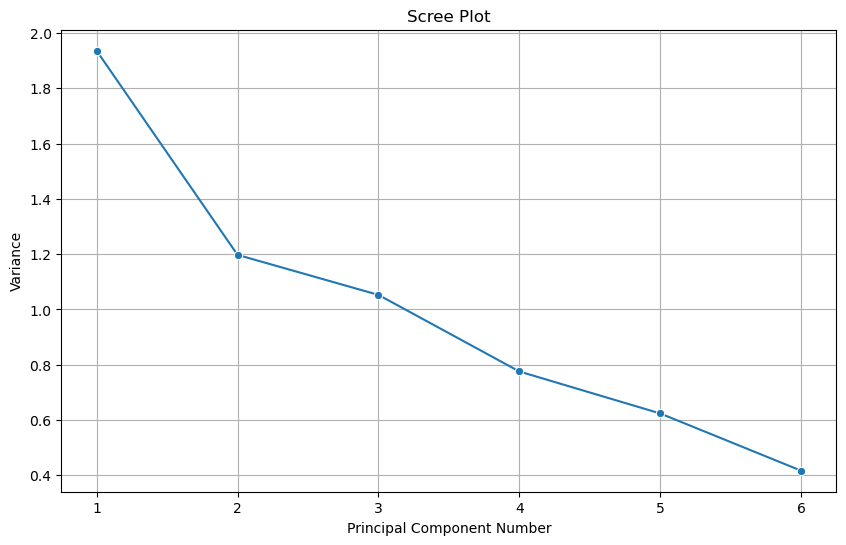

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

explained_variance = pc_x.var()

# Plot the scree plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(explained_variance) + 1), y=explained_variance.values, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component Number')
plt.ylabel('Variance')
plt.grid(True)
plt.show()

In [ ]:
"" Variance for PC1: 1.23
 Variance for PC2: 1.07
 Variance for PC3: 0.78
Variance for PC4: 0.57
 Variance for PC5: 0.43
  Variance for PC6: 0.40
""""
The 'elbow' appears to be around 4 principal components (PC4), 
as the curve  flattening becomes around pc=4 :no siginifcant droping of  variance after this
This suggests that retaining 4 components may be  suitable

In [97]:
from sklearn.decomposition import PCA

# Apply PCA with 4 components to the standardized feature set (X)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

# Create a new df with the 4 principal components
X_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])

print("PCA with 4 components applied successfully.")
display(X_pca.head())

PCA with 4 components applied successfully.


,PC1,PC2,PC3,PC4
0,0.833532,-2.028565,-0.746442,-0.077949
1,0.978225,-1.789406,-0.464046,-0.577816
2,1.396002,-1.637763,0.200569,-1.068373
3,2.873990,-1.154960,1.658272,-0.985852
4,3.068662,-0.816801,1.680333,-0.976434


In [98]:
from sklearn.decomposition import PCA
import pandas as pd

# 
pca = PCA(n_components=4)

# Fit and transform X features
X_pca_array = pca.fit_transform(X)

# Convert the X_pca_array into a df
X_pca = pd.DataFrame(X_pca_array)

# Assign column names to X_pca
X_pca.columns = ['PC1', 'PC2', 'PC3', 'PC4']


print("PCA with 4 components applied successfully.")

# Display few rows of the X_pca DataFrame
X_pca.head()

PCA with 4 components applied successfully.


,PC1,PC2,PC3,PC4
0,0.833532,-2.028565,-0.746442,-0.077949
1,0.978225,-1.789406,-0.464046,-0.577816
2,1.396002,-1.637763,0.200569,-1.068373
3,2.873990,-1.154960,1.658272,-0.985852
4,3.068662,-0.816801,1.680333,-0.976434


In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split the PCA-transformed data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

#  Linear Regression model
linear_model_pca = LinearRegression()

# Train the model using PCA data
linear_model_pca.fit(X_train_pca, y_train_pca)

print("Linear Regression model  with PCA-transformed data.")

Linear Regression model  with PCA-transformed data.


In [100]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the PCA test data
y_pred_pca_test = linear_model_pca.predict(X_test_pca)

# Make predictions on the PCA- training set
y_pred_pca_train = linear_model_pca.predict(X_train_pca)

# Evaluate the Linear Regression model with PCA test data
mse_pca = mean_squared_error(y_test_pca, y_pred_pca_test)
r2_pca_test = r2_score(y_test_pca, y_pred_pca_test)

# Evaluate the Linear Regression model with PCA on the training set
r2_pca_train = r2_score(y_train_pca, y_pred_pca_train)

print(f"Linear Regression (PCA) Mean Squared Error on Test Set: {mse_pca:.2f}")
print(f"Linear Regression (PCA) R-squared on Test Set: {r2_pca_test:.2f}")
print(f"Linear Regression (PCA) R-squared on Training Set: {r2_pca_train:.2f}")

Linear Regression (PCA) Mean Squared Error on Test Set: 45119322.88
Linear Regression (PCA) R-squared on Test Set: 0.57
Linear Regression (PCA) R-squared on Training Set: 0.61


In [ ]:
"""  given that the R-squared is around 0.63 for the original features and 0.57 for PCA,
it suggests there might be more non-linear relationships 
Hence proceeding to other models

In [ ]:
#                                                      DECISION TREE

In [101]:
##Decision Tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np



# Split the data into training and testing sets

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train_dt, y_train_dt)

# Make predictions on the test set
y_pred_dt_test = dt_model.predict(X_test_dt)

# Evaluate the model on the test set
mse_dt = mean_squared_error(y_test_dt, y_pred_dt_test)
r2_dt_test = r2_score(y_test_dt, y_pred_dt_test)
rmse_dt = np.sqrt(mse_dt)

# Make predictions on the training data
y_pred_dt_train = dt_model.predict(X_train_dt)

# Evaluate the model on the training set
r2_dt_train = r2_score(y_train_dt, y_pred_dt_train)

print(f"Mean Squared Error (Decision Tree Test): {mse_dt:.2f}")
print(f"Root Mean Squared Error (Decision Tree Test): {rmse_dt:.2f}")
print(f"R-squared (Decision Tree Test): {r2_dt_test:.2f}")
print(f"R-squared (Decision Tree Train): {r2_dt_train:.2f}")

Mean Squared Error (Decision Tree Test): 20518118.74
Root Mean Squared Error (Decision Tree Test): 4529.69
R-squared (Decision Tree Test): 0.81
R-squared (Decision Tree Train): 1.00
